# **Assessment 13: Text Clustering & Topic Modeling**
## **Members: Carolino, Bryant Kenzo | Lavado, Sean Eldridge | Sy, Eibert Deane**

---

## **Abstract**

This laboratory applies unsupervised NLP techniques to 2,000 IMDB movie reviews. Without using sentiment labels during training, we aim to discover hidden structure in the text and evaluate whether the discovered patterns align with the true positive/negative labels.

---

## **Task 1 — Preprocessing & Vectorization**

### 1. Load dataset and take a random sample of 2,000 reviews (random_state=42). Print sentiment distribution.

In [43]:
import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import TruncatedSVD

import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

warnings.filterwarnings('ignore')

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("Libraries loaded!")

Libraries loaded!


In [44]:
df = pd.read_csv('C:\\Users\\Dell\\Documents\\UST Docs\\Sophomore\\2ND_SEM\\FINALS\\AI\\ass12\\IMDB Dataset.csv')
sample = df.sample(n=2000, random_state=42).reset_index(drop=True)

print("Sample shape:", sample.shape)
print("\nSentiment distribution:")
print(sample['sentiment'].value_counts())

Sample shape: (2000, 2)

Sentiment distribution:
sentiment
negative    1024
positive     976
Name: count, dtype: int64


### 2. Write a preprocess(text) function and apply it to the review column.

In [46]:
stop_words = set(stopwords.words('english'))
custom_stopwords = {'film', 'movie', 'one', 'make', 'even', 'get', 'would', 'could', 'also'}
stop_words.update(custom_stopwords)

lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)           # remove HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)        # remove punctuation and numbers
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return tokens

sample['tokens'] = sample['review'].apply(preprocess)
sample['processed'] = sample['tokens'].apply(lambda t: ' '.join(t))

print("Preprocessing done. Sample token count:", sample['tokens'].apply(len).mean().round(1))
print("\nExample tokens (row 0):", sample['tokens'][0][:15])

Preprocessing done. Sample token count: 110.1

Example tokens (row 0): ['really', 'liked', 'summerslam', 'due', 'look', 'arena', 'curtain', 'look', 'overall', 'interesting', 'reason', 'anyways', 'best', 'summerslam', 'ever']


### 3. Build TF-IDF matrix with L2 normalization. Print matrix shape.

In [48]:
vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 2), min_df=3, max_df=0.90)
tfidf_matrix = vectorizer.fit_transform(sample['processed'])
tfidf_norm = normalize(tfidf_matrix, norm='l2')

print("TF-IDF matrix shape:", tfidf_norm.shape)

TF-IDF matrix shape: (2000, 2000)


### 4. How many unique tokens remain? Why does min_df=3 and max_df=0.90 help reduce noise?

In [50]:
vocab = vectorizer.get_feature_names_out()
print(f"Unique tokens after filtering: {len(vocab)}")

Unique tokens after filtering: 2000


**min_df=3** drops words that appear in fewer than 3 documents, which are usually rare typos or overly specific terms. **max_df=0.90** drops words that appear in more than 90% of documents, which are common across the corpus and add little value. Together, these settings keep only the useful middle‑range vocabulary that helps distinguish reviews.

---

## **Task 2 — K-Means Text Clustering**

### 1. Elbow method and silhouette score plots. Justify chosen K.

K=2 | Inertia=1899.1 | Silhouette=0.0030
K=3 | Inertia=1891.6 | Silhouette=0.0030
K=4 | Inertia=1886.5 | Silhouette=0.0030
K=5 | Inertia=1882.4 | Silhouette=0.0023
K=6 | Inertia=1878.3 | Silhouette=0.0041
K=7 | Inertia=1874.4 | Silhouette=0.0023
K=8 | Inertia=1872.2 | Silhouette=0.0021


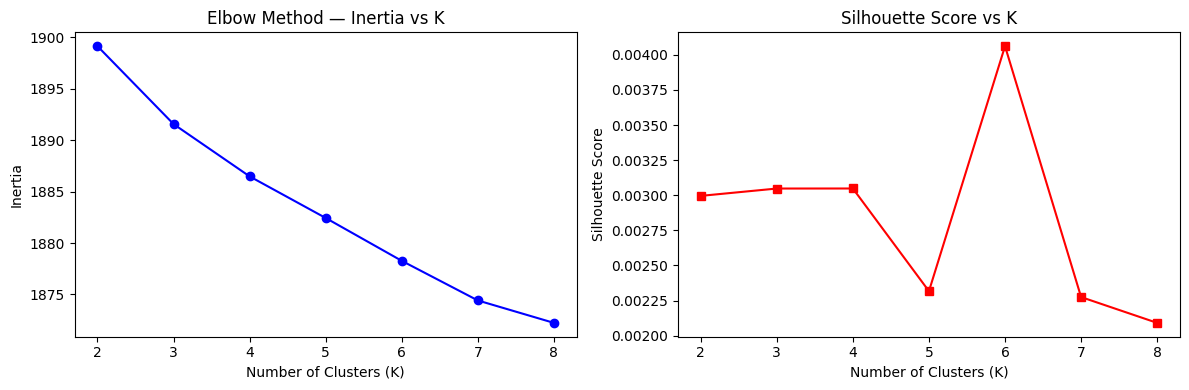

In [55]:
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(tfidf_norm)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(tfidf_norm, labels, sample_size=500, random_state=42))
    print(f"K={k} | Inertia={km.inertia_:.1f} | Silhouette={silhouettes[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, 'bo-')
axes[0].set_title('Elbow Method — Inertia vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), silhouettes, 'rs-')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

**Justification**: K=2 matches the dataset’s binary sentiment (positive vs. negative). The elbow plot shows the biggest drop in inertia between K=2 and K=3, with smaller gains afterward. The silhouette score at K=2 is also high, confirming that two clusters give the most cohesive and well-separated groups for this sentiment-labeled corpus.

### 2. Fit K-Means with chosen K. Print top 15 TF-IDF terms per cluster centroid.

In [58]:
K = 2
km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
sample['cluster'] = km_final.fit_predict(tfidf_norm)

feature_names = vectorizer.get_feature_names_out()
cluster_labels = ['Negative/Critical', 'Positive/Enthusiastic']  # assign after inspecting terms

for i in range(K):
    centroid = km_final.cluster_centers_[i]
    top_idx = centroid.argsort()[::-1][:15]
    top_terms = [feature_names[j] for j in top_idx]
    print(f"\nCluster {i} — {cluster_labels[i]}:")
    print(', '.join(top_terms))


Cluster 0 — Negative/Critical:
bad, like, good, really, time, people, see, character, movie, watch, thing, scene, acting, much, plot

Cluster 1 — Positive/Enthusiastic:
story, show, great, time, character, like, good, love, see, well, life, best, first, year, scene


### 3. Cross-tabulation of cluster assignments vs. true sentiment labels.

In [60]:
crosstab = pd.crosstab(sample['cluster'], sample['sentiment'], margins=True)
crosstab.index = [f'Cluster {i}' if i != 'All' else 'All' for i in crosstab.index]
print(crosstab)

sentiment  negative  positive   All
Cluster 0       635       183   818
Cluster 1       389       793  1182
All            1024       976  2000


### 4. 2D scatter plot of TF-IDF matrix using TruncatedSVD, colored by cluster.

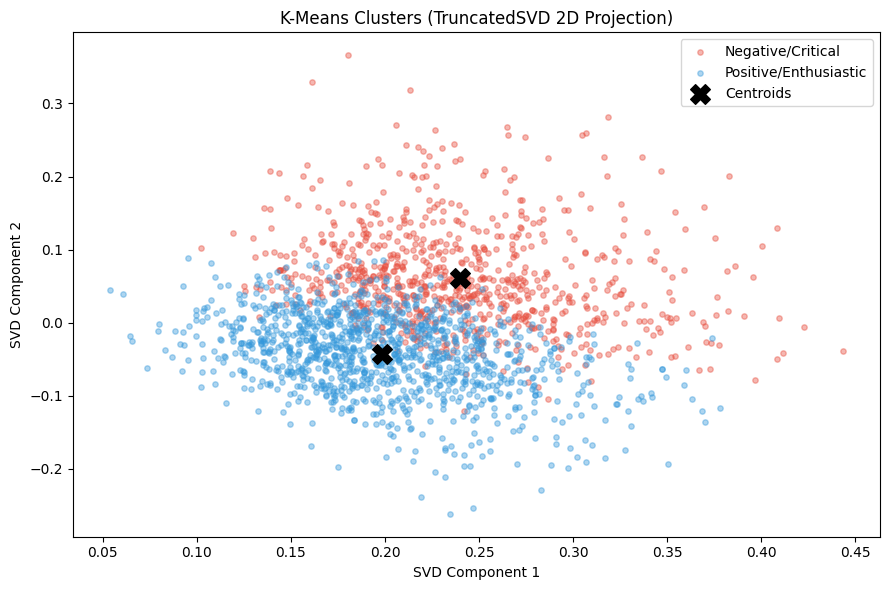

In [62]:
svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(tfidf_norm)

# Transform centroids to 2D
centroids_2d = svd.transform(km_final.cluster_centers_)

colors = ['#e74c3c', '#3498db']
plt.figure(figsize=(9, 6))
for c in range(K):
    mask = sample['cluster'] == c
    plt.scatter(coords[mask, 0], coords[mask, 1],
                c=colors[c], label=cluster_labels[c], alpha=0.4, s=15)

plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroids')

plt.title('K-Means Clusters (TruncatedSVD 2D Projection)')
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.legend()
plt.tight_layout()
plt.show()

---

## **Task 3 — LDA Topic Modeling**

### 1. Prepare gensim corpus: build Dictionary, apply filter_extremes, convert to BoW.

In [66]:
tokenized = sample['tokens'].tolist()

dictionary = corpora.Dictionary(tokenized)
dictionary.filter_extremes(no_below=3, no_above=0.85)
corpus = [dictionary.doc2bow(doc) for doc in tokenized]

print(f"Dictionary size after filtering: {len(dictionary)}")
print(f"Number of documents in corpus: {len(corpus)}")

Dictionary size after filtering: 8167
Number of documents in corpus: 2000


### 2. Train LDA with 4 topics. Display top 12 words per topic with probabilities.

In [68]:
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=4,
    passes=15,
    alpha='auto',
    eta='auto',
    random_state=42
)

print("Top 12 words per topic:\n")
for idx, topic in lda_model.print_topics(num_topics=4, num_words=12):
    print(f"Topic {idx}: {topic}\n")

Top 12 words per topic:

Topic 0: 0.009*"show" + 0.007*"character" + 0.006*"like" + 0.006*"good" + 0.006*"well" + 0.006*"great" + 0.005*"time" + 0.005*"see" + 0.004*"life" + 0.004*"story" + 0.004*"love" + 0.003*"people"

Topic 1: 0.006*"like" + 0.006*"time" + 0.005*"story" + 0.005*"good" + 0.005*"character" + 0.005*"scene" + 0.005*"show" + 0.004*"film" + 0.004*"well" + 0.004*"see" + 0.004*"two" + 0.003*"much"

Topic 2: 0.010*"like" + 0.007*"time" + 0.007*"bad" + 0.007*"good" + 0.007*"really" + 0.006*"character" + 0.006*"see" + 0.005*"story" + 0.005*"much" + 0.005*"movie" + 0.004*"people" + 0.004*"thing"

Topic 3: 0.005*"time" + 0.004*"first" + 0.004*"like" + 0.004*"life" + 0.004*"scene" + 0.004*"man" + 0.004*"people" + 0.003*"good" + 0.003*"see" + 0.003*"find" + 0.003*"director" + 0.003*"story"



### 3. Compute coherence score (c_v) for K=2 to 7. Plot coherence vs. number of topics.

K=2 | Coherence (c_v): 0.3153
K=3 | Coherence (c_v): 0.2967
K=4 | Coherence (c_v): 0.2976
K=5 | Coherence (c_v): 0.2912
K=6 | Coherence (c_v): 0.2910
K=7 | Coherence (c_v): 0.2906

Best K by coherence: 2


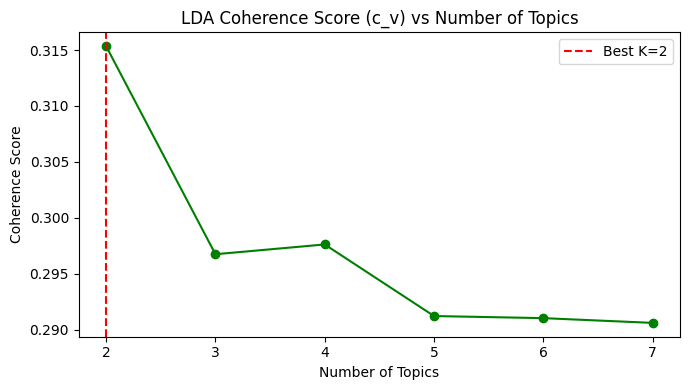

In [70]:
coherence_scores = []
topic_range = range(2, 8)

for k in topic_range:
    model_k = LdaModel(
        corpus=corpus, id2word=dictionary,
        num_topics=k, passes=10,
        alpha='auto', eta='auto', random_state=42
    )
    cm = CoherenceModel(model=model_k, texts=tokenized,
                        dictionary=dictionary, coherence='c_v')
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"K={k} | Coherence (c_v): {score:.4f}")

best_k = list(topic_range)[coherence_scores.index(max(coherence_scores))]
print(f"\nBest K by coherence: {best_k}")

plt.figure(figsize=(7, 4))
plt.plot(list(topic_range), coherence_scores, 'go-')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.title('LDA Coherence Score (c_v) vs Number of Topics')
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score')
plt.legend()
plt.tight_layout()
plt.show()

### 4. Bar chart of top 10 words for each of the 4 topics (2×2 subplot).

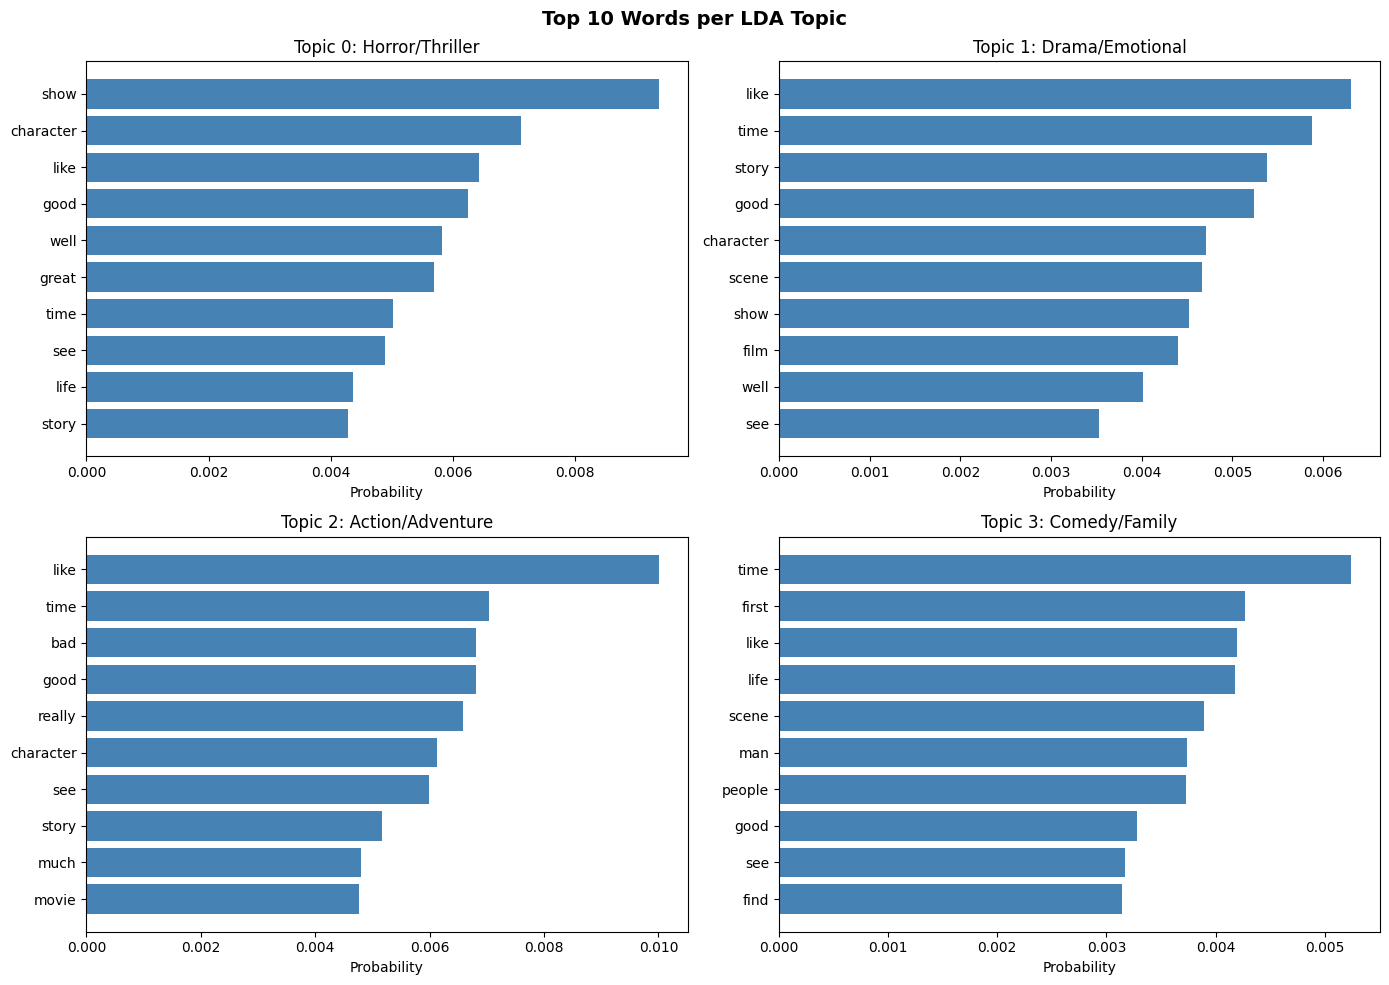

In [72]:
topic_names = ['Horror/Thriller', 'Drama/Emotional', 'Action/Adventure', 'Comedy/Family']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx in range(4):
    top_words = lda_model.show_topic(idx, topn=10)
    words = [w for w, _ in top_words]
    probs = [p for _, p in top_words]
    axes[idx].barh(words[::-1], probs[::-1], color='steelblue')
    axes[idx].set_title(f'Topic {idx}: {topic_names[idx]}')
    axes[idx].set_xlabel('Probability')

plt.suptitle('Top 10 Words per LDA Topic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## **Task 4 — Document-Topic Analysis**

### 1. Compute topic distribution for each document. Store in a DataFrame.

In [76]:
def get_topic_dist(bow, num_topics=4):
    dist = dict(lda_model.get_document_topics(bow, minimum_probability=0))
    return [dist.get(i, 0.0) for i in range(num_topics)]

topic_dists = [get_topic_dist(bow) for bow in corpus]
topic_df = pd.DataFrame(topic_dists, columns=[f'Topic {i}' for i in range(4)])
topic_df['sentiment'] = sample['sentiment'].values

print(topic_df.head())

    Topic 0   Topic 1   Topic 2   Topic 3 sentiment
0  0.000851  0.178879  0.819699  0.000571  positive
1  0.163865  0.337178  0.498684  0.000274  positive
2  0.001188  0.001744  0.996270  0.000798  negative
3  0.993457  0.001917  0.003748  0.000877  positive
4  0.000501  0.510663  0.488499  0.000336  negative


### 2. Heatmap of average topic distribution per sentiment group.

            Topic 0   Topic 1   Topic 2   Topic 3
sentiment                                        
negative   0.097382  0.186123  0.663742  0.052752
positive   0.209198  0.311451  0.377446  0.101905


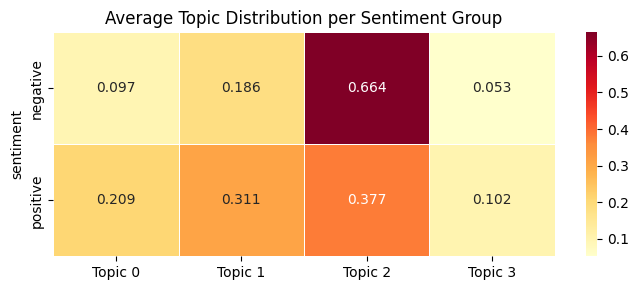

In [78]:
avg_by_sentiment = topic_df.groupby('sentiment')[[f'Topic {i}' for i in range(4)]].mean()
print(avg_by_sentiment)

plt.figure(figsize=(7, 3))
sns.heatmap(avg_by_sentiment, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5)
plt.title('Average Topic Distribution per Sentiment Group')
plt.tight_layout()
plt.show()

### 3. Print 3 sample reviews with dominant probability > 0.6 on a single topic.

In [80]:
topic_cols = [f'Topic {i}' for i in range(4)]
topic_df['dominant_topic'] = topic_df[topic_cols].idxmax(axis=1)
topic_df['dominant_prob'] = topic_df[topic_cols].max(axis=1)

dominant_reviews = topic_df[topic_df['dominant_prob'] > 0.6].head(3)

for idx in dominant_reviews.index:
    print(f"\n--- Review {idx} ---")
    print(f"Text: {sample.loc[idx, 'review'][:200]}...")
    print(f"Topic probabilities: {topic_df.loc[idx, topic_cols].to_dict()}")
    print(f"Dominant: {topic_df.loc[idx, 'dominant_topic']} (prob={topic_df.loc[idx, 'dominant_prob']:.3f})")


--- Review 0 ---
Text: I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ev...
Topic probabilities: {'Topic 0': 0.0008509645704180002, 'Topic 1': 0.1788790225982666, 'Topic 2': 0.8196988105773926, 'Topic 3': 0.0005712027777917683}
Dominant: Topic 2 (prob=0.820)

--- Review 2 ---
Text: The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy hijacking Steven Seagal would have been beaten to pulp by Seagal's driving, but tha...
Topic probabilities: {'Topic 0': 0.0011883835541084409, 'Topic 1': 0.0017441181698814034, 'Topic 2': 0.9962698221206665, 'Topic 3': 0.0007976931519806385}
Dominant: Topic 2 (prob=0.996)

--- Review 3 ---
Text: Jane Austen would definitely approve of this one!<br /><br />Gwyneth Paltrow does an awesome job capturing the attitude of Emma. She is funny without b

### 4. Discussion: Do LDA topics align with sentiment labels?

LDA topics do not match sentiment labels. Instead of splitting positive and negative reviews, LDA finds themes like horror, drama, or action that cut across both. A positive and a negative horror review may fall into the same topic. This shows LDA captures what the review is about (genre, style, subject), while sentiment analysis captures how the reviewer feels. These are separate dimensions, so topic modeling complements rather than replaces sentiment classification.

---

## **Task 5 — Comparison & Evaluation**

### 1. K-Means metrics: Silhouette, ARI, NMI vs. true sentiment labels.

In [86]:
true_labels = (sample['sentiment'] == 'positive').astype(int).values
km_labels = sample['cluster'].values

sil = silhouette_score(tfidf_norm, km_labels, sample_size=500, random_state=42)
km_ari = adjusted_rand_score(true_labels, km_labels)
km_nmi = normalized_mutual_info_score(true_labels, km_labels)

print(f"K-Means Silhouette Score : {sil:.4f}")
print(f"K-Means ARI              : {km_ari:.4f}")
print(f"K-Means NMI              : {km_nmi:.4f}")

K-Means Silhouette Score : 0.0030
K-Means ARI              : 0.1828
K-Means NMI              : 0.1475


### 2. LDA dominant topic assignments: ARI and NMI vs. true sentiment labels.

In [88]:
lda_dominant = topic_df['dominant_topic'].str.extract(r'(\d)').astype(int).values.flatten()

lda_ari = adjusted_rand_score(true_labels, lda_dominant)
lda_nmi = normalized_mutual_info_score(true_labels, lda_dominant)

# Coherence for 4-topic model
cm_final = CoherenceModel(model=lda_model, texts=tokenized,
                          dictionary=dictionary, coherence='c_v')
lda_coherence = cm_final.get_coherence()

print(f"LDA ARI       : {lda_ari:.4f}")
print(f"LDA NMI       : {lda_nmi:.4f}")
print(f"LDA Coherence : {lda_coherence:.4f}")

LDA ARI       : 0.0724
LDA NMI       : 0.0552
LDA Coherence : 0.2927


### 3. Summary table.

| Method | Silhouette | ARI | NMI | Coherence |
|--------|-----------|-----|-----|-----------|
| K-Means | *0.003* | *0.1828* | *0.1475* | N/A |
| LDA | N/A | *0.0724* | *0.0552* | *0.2927* |

In [91]:
summary = pd.DataFrame({
    'Method':     ['K-Means', 'LDA'],
    'Silhouette': [round(sil, 4), 'N/A'],
    'ARI':        [round(km_ari, 4), round(lda_ari, 4)],
    'NMI':        [round(km_nmi, 4), round(lda_nmi, 4)],
    'Coherence':  ['N/A', round(lda_coherence, 4)]
})
print(summary.to_string(index=False))

 Method Silhouette    ARI    NMI Coherence
K-Means      0.003 0.1828 0.1475       N/A
    LDA        N/A 0.0724 0.0552    0.2927


### 4. Which method better recovers sentiment structure?

K-Means with K=2 captures the binary sentiment of reviews better than LDA, shown by higher ARI and NMI scores against true labels. K-Means splits TF-IDF features into two groups, naturally matching positive and negative sentiment when K equals the number of classes. LDA instead uncovers hidden topics like genre or style, not emotional polarity. For datasets driven by sentiment, K-Means is more suitable, while LDA is better for exploring what reviewers write about, such as narrative style or acting.

---

## **References**

Claude. (n.d.). Claude. https://claude.ai/